In [1]:
#import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
#Load data
data=pd.read_excel("/Users/asmitabaul/Downloads/Gold price prediction final.xlsx")
data.head()

,Date,Gold Price,USD,Brent,Repo,CPI,Lag 1
0,2016-01-01,24943,66.30,36.00,6.75,5.69,0
1,2016-01-04,25423,66.43,36.28,6.75,5.69,24943
2,2016-01-05,25430,66.59,35.56,6.75,5.69,25423
3,2016-01-06,25756,66.70,33.89,6.75,5.69,25430
4,2016-01-07,26106,66.85,33.57,6.75,5.69,25756


In [3]:
data['Date'] = pd.to_datetime(data['Date'])
date = data.sort_values('Date')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2514 non-null   datetime64[ns]
 1   Gold Price  2514 non-null   int64         
 2   USD         2514 non-null   float64       
 3   Brent       2514 non-null   float64       
 4   Repo        2514 non-null   float64       
 5   CPI         2514 non-null   float64       
 6   Lag 1       2514 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 137.6 KB


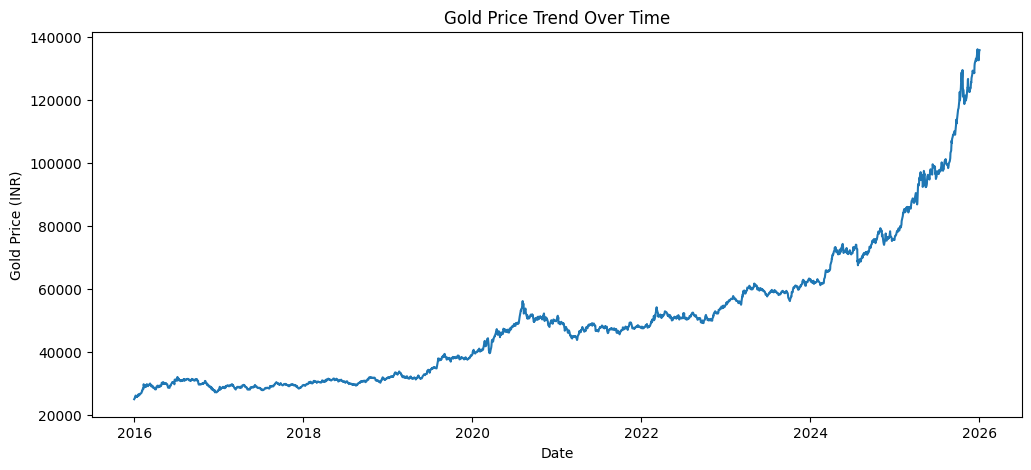

In [4]:
#EDA:
plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['Gold Price'])
plt.xlabel("Date")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price Trend Over Time")
plt.show()

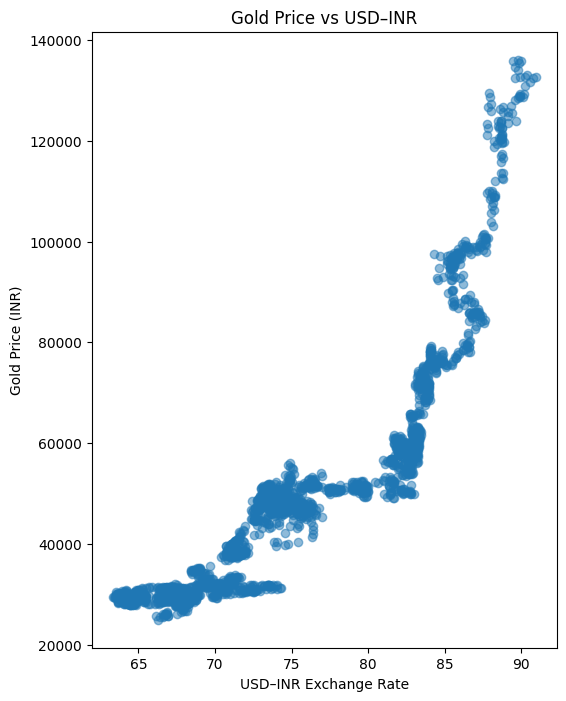

In [5]:
plt.figure(figsize=(6,8))
plt.scatter(data['USD'], data['Gold Price'], alpha=0.5)
plt.xlabel("USD–INR Exchange Rate")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price vs USD–INR")
plt.show()

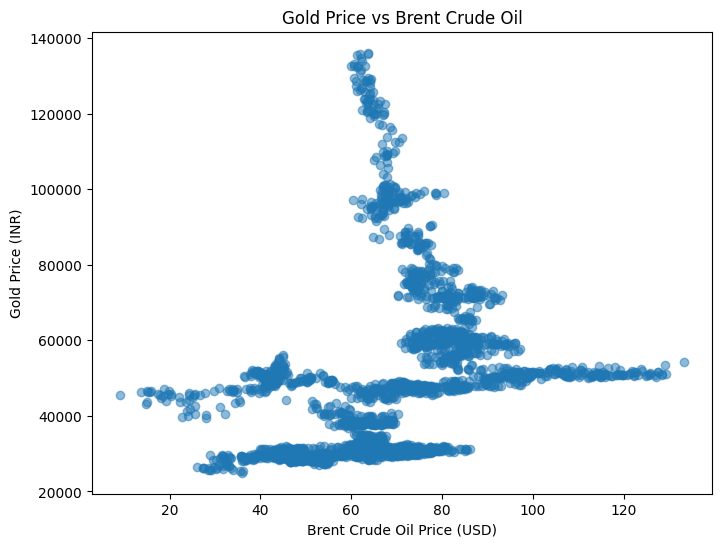

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(data['Brent'], data['Gold Price'], alpha=0.5)
plt.xlabel("Brent Crude Oil Price (USD)")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price vs Brent Crude Oil")
plt.show()

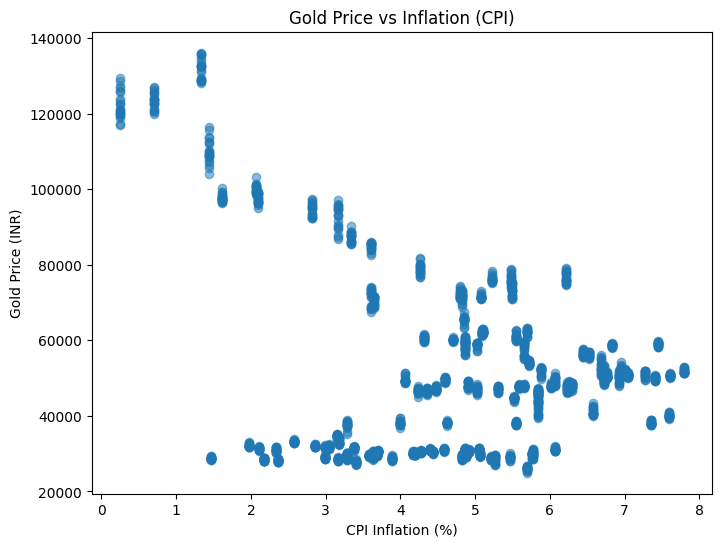

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(data['CPI'], data['Gold Price'], alpha=0.5)
plt.xlabel("CPI Inflation (%)")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price vs Inflation (CPI)")
plt.show()

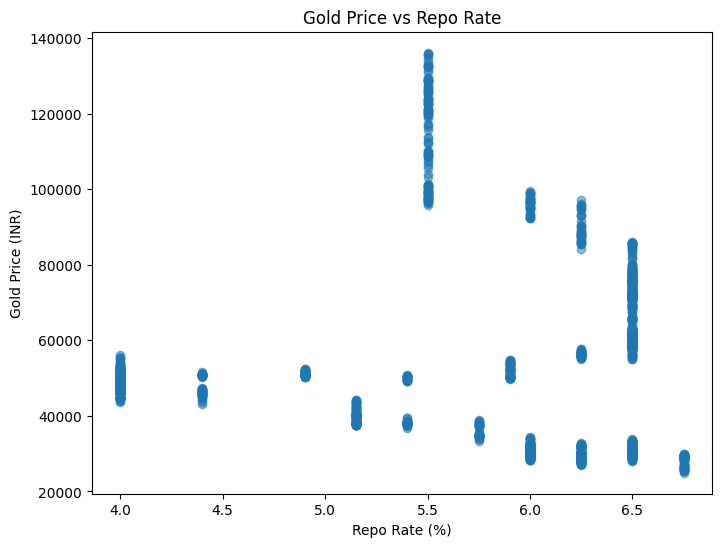

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(data['Repo'], data['Gold Price'], alpha=0.5)
plt.xlabel("Repo Rate (%)")
plt.ylabel("Gold Price (INR)")
plt.title("Gold Price vs Repo Rate")
plt.show()

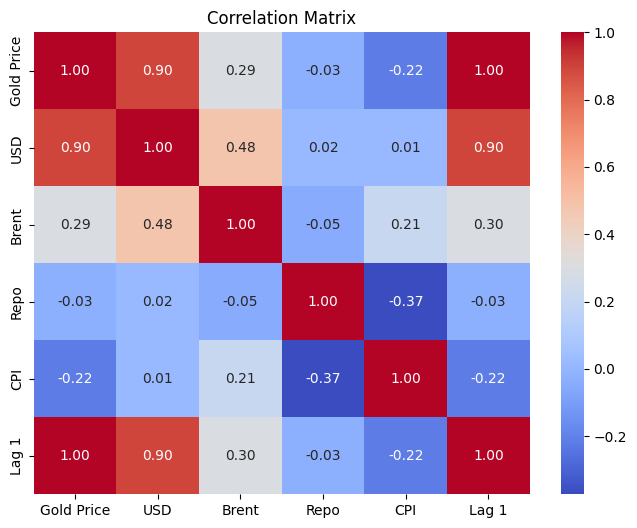

In [9]:
plt.figure(figsize=(8,6))
corr = data.drop(columns=['Date']).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [10]:
#feature selection
x = data.drop(columns=['Date', 'Gold Price'])
y = data['Gold Price']
print(x)
print(y)

         USD  Brent  Repo   CPI   Lag 1
0     66.300  36.00  6.75  5.69       0
1     66.430  36.28  6.75  5.69   24943
2     66.590  35.56  6.75  5.69   25423
3     66.700  33.89  6.75  5.69   25430
4     66.850  33.57  6.75  5.69   25756
...      ...    ...   ...   ...     ...
2509  89.814  63.70  5.50  1.33  135799
2510  89.900  63.10  5.50  1.33  136104
2511  89.770  62.30  5.50  1.33  132595
2512  89.871  61.35  5.50  1.33  133974
2513  90.014  61.98  5.50  1.33  135454

[2514 rows x 5 columns]
0        24943
1        25423
2        25430
3        25756
4        26106
         ...  
2509    136104
2510    132595
2511    133974
2512    135454
2513    135793
Name: Gold Price, Length: 2514, dtype: int64


In [11]:
#Model training and evaluation
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=False
)

In [12]:
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 1398.9397762242322
RMSE: 3254011.193069995
R²: 0.9916000781183271


In [13]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

y_pred_ridge = ridge.predict(x_test)

print("Ridge Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", mean_squared_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred_ridge))

Ridge Regression Results:
MAE: 1398.5867020769633
RMSE: 3252595.7050033095
R²: 0.9916037320667861


In [14]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 24142.004373442243
RMSE: 968410990.4151076
R²: -1.499861305383484


In [15]:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

print("XGBoost Results")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", mean_squared_error(y_test, y_pred_xgb))
print("R²:", r2_score(y_test, y_pred_xgb))

XGBoost Results
MAE: 24391.29296875
RMSE: 995420096.0
R²: -1.5695829391479492


In [24]:
#prediction 
new_data = pd.read_excel("/Users/asmitabaul/Downloads/new_data_gold.xlsx")

new_data_r=new_data.drop(columns="Date")
n_pred_r = ridge.predict(new_data_r)

new_data_r["Predicted_Gold_Price_Ridge"] = n_pred_r
print("Ridge Regression Prediction:\n", new_data_r)


Ridge Regression Prediction:
       USD  Brent  Repo   CPI   Lag 1  Predicted_Gold_Price_Ridge
0   91.00   70.0   5.5  2.75  157800               153913.058395
1   91.10   70.5   5.5  2.75  158200               154301.704418
2   91.20   71.0   5.5  2.75  158500               154594.745902
3   91.30   70.8   5.5  2.75  158900               154984.627167
4   91.40   71.2   5.5  2.75  159200               155277.845115
5   91.50   71.5   5.5  2.75  159600               155666.844064
6   91.60   72.0   5.5  2.75  160000               156055.490088
7   91.55   71.8   5.5  2.75  160400               156434.706082
8   91.65   72.2   5.5  2.75  160800               156823.528568
9   91.70   72.5   5.5  2.75  161200               157208.972427
10  91.80   72.8   5.5  2.75  161600               157597.971377
11  91.90   73.0   5.5  2.75  162000               157987.146790
12  92.00   73.2   5.5  2.75  162300               158280.717663
13  91.95   73.0   5.5  2.75  162700               158659.93

In [25]:
new_data_lr = new_data.drop(columns="Date")

n_pred_lr = lr.predict(new_data_lr)

new_data_lr["Predicted_Gold_Price_LR"] = n_pred_lr
print("Linear Regression Prediction:\n", new_data_lr)


Linear Regression Prediction:
       USD  Brent  Repo   CPI   Lag 1  Predicted_Gold_Price_LR
0   91.00   70.0   5.5  2.75  157800            153911.785304
1   91.10   70.5   5.5  2.75  158200            154300.427636
2   91.20   71.0   5.5  2.75  158500            154593.466893
3   91.30   70.8   5.5  2.75  158900            154983.344826
4   91.40   71.2   5.5  2.75  159200            155276.560597
5   91.50   71.5   5.5  2.75  159600            155665.555958
6   91.60   72.0   5.5  2.75  160000            156054.198290
7   91.55   71.8   5.5  2.75  160400            156433.407321
8   91.65   72.2   5.5  2.75  160800            156822.226167
9   91.70   72.5   5.5  2.75  161200            157207.665227
10  91.80   72.8   5.5  2.75  161600            157596.660588
11  91.90   73.0   5.5  2.75  162000            157985.832464
12  92.00   73.2   5.5  2.75  162300            158279.401264
13  91.95   73.0   5.5  2.75  162700            158658.610294
14  92.10   73.5   5.5  2.75  163100   

In [24]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "RMSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb)
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,1398.939776,3.254011e+06,0.991600
1,Ridge Regression,1398.586702,3.252596e+06,0.991604
2,Random Forest,24142.004373,9.684110e+08,-1.499861
3,XGBoost,24391.292969,9.954201e+08,-1.569583


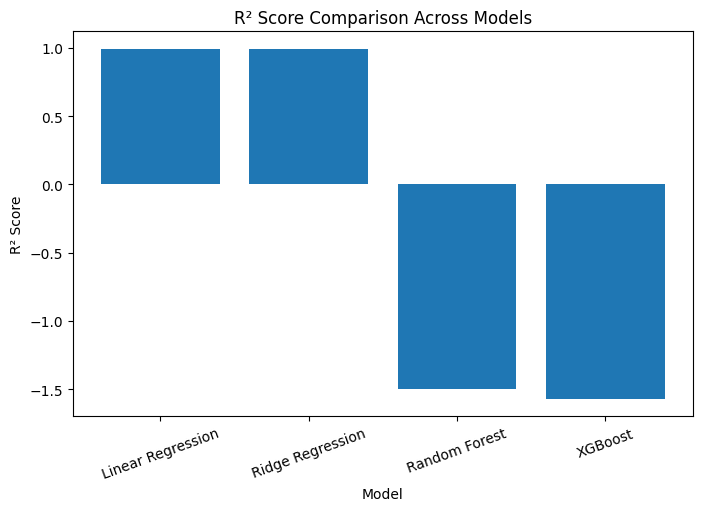

In [19]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison Across Models")
plt.xticks(rotation=20)
plt.show()

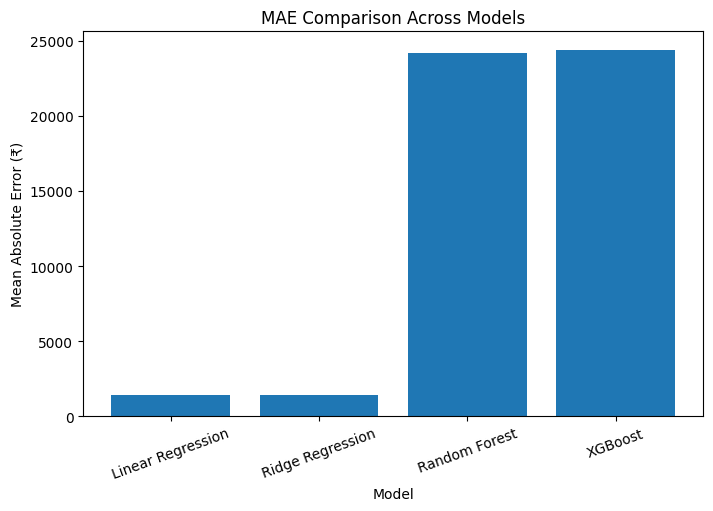

In [20]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAE"])
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (₹)")
plt.title("MAE Comparison Across Models")
plt.xticks(rotation=20)
plt.show()

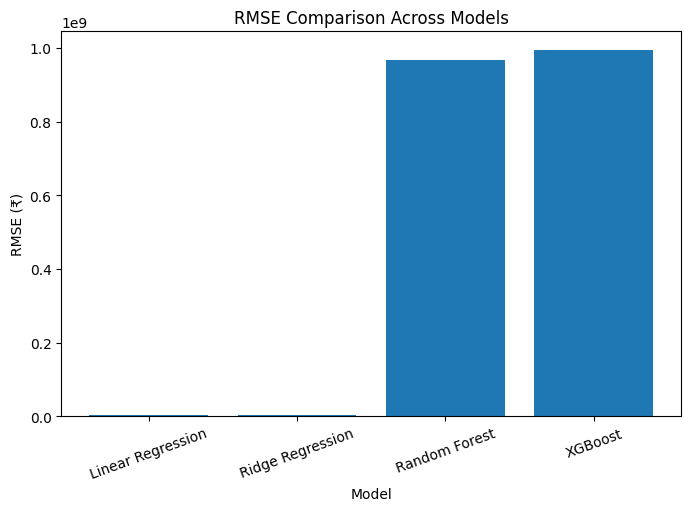

In [21]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE (₹)")
plt.title("RMSE Comparison Across Models")
plt.xticks(rotation=20)
plt.show()

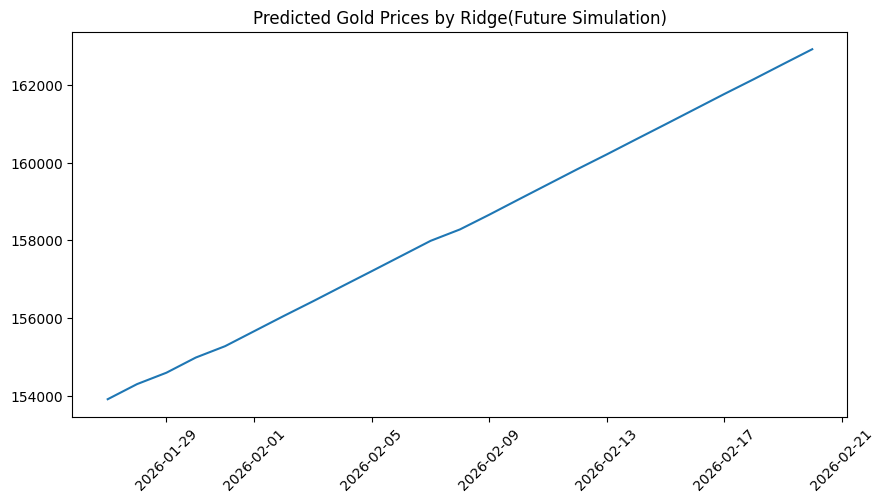

In [27]:
plt.figure(figsize=(10,5))
plt.plot(new_data['Date'], new_data_r['Predicted_Gold_Price_Ridge'])
plt.xticks(rotation=45)
plt.title("Predicted Gold Prices by Ridge(Future Simulation)")
plt.show()

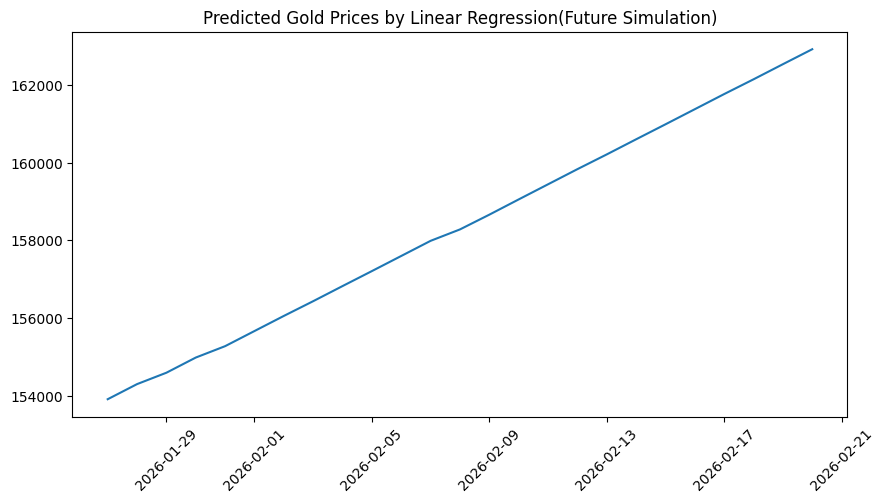

In [29]:
plt.figure(figsize=(10,5))
plt.plot(new_data['Date'], new_data_lr['Predicted_Gold_Price_LR'])
plt.xticks(rotation=45)
plt.title("Predicted Gold Prices by Linear Regression(Future Simulation)")
plt.show()